# ViT pruning — thesis figures

Compact version of the layer-metrics viz, focused on figures that earn their place in the thesis chapter. Seven figures, each answering one question:

1. **Master heatmap** — full result matrix, all algorithms × all block widths
2. **Block-width sweep (score)** — where does each algorithm pay off?
3. **Block-width sweep (accuracy)** — at what block width does pruning destroy the model?
4. **Score↔accuracy tradeoff** — overlay of the two above, the thesis money figure
5. **Per-layer comparison at narrow vs wide blocks (1×2 + 1×16)** — does the algorithm ranking depend on layer type?
6. **Score → rel_error validation** — does the cheap metric track the real one?
7. **Pruning time cost** — what does GA-TETRIS cost wall-clock-wise?

All data comes from CSVs in `benchmark_csvs_vit/`. No scrapbook reads, no executed-notebook reads.

## Setup

In [21]:
%load_ext autoreload
%autoreload 2

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

OUTPUT_FOLDER = "benchmark_csvs_vit"

LAYER_TYPES = ["attn.qkv", "attn.proj", "mlp.fc1", "mlp.fc2"]
LAYER_GROUP = {"attn.qkv": "Attention", "attn.proj": "Attention",
               "mlp.fc1": "MLP", "mlp.fc2": "MLP"}

# Consistent colors per algorithm
ALG_COLORS = {
    "GA-TETRIS":             "#d62728",
    "Original TETRIS":       "#1f77b4",
    "Sort-by-Norm":          "#2ca02c",
    "Block-Wanda":           "#ff7f0e",
    "Random":                "#9467bd",
    "Random-Swaps":          "#8c564b",
    "Random-Swaps (sorted)": "#17becf",
    "No prune":              "#7f7f7f",
}
def alg_color(alg):
    return ALG_COLORS.get(alg, "#555555")

LAYER_COLORS = {
    "attn.qkv":  "#1f77b4",
    "attn.proj": "#d62728",
    "mlp.fc1":   "#9467bd",
    "mlp.fc2":   "#8c564b",
}
def layer_color(lt):
    return LAYER_COLORS.get(lt, "#555555")

# Display order for algorithms in plots — best at top
ALG_ORDER = ["GA-TETRIS", "Original TETRIS", "Sort-by-Norm",
             "Random-Swaps (sorted)", "Random-Swaps", "Block-Wanda"]
def alg_sort_key(a):
    return ALG_ORDER.index(a) if a in ALG_ORDER else 99


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load

In [22]:
_LAYER_RE = re.compile(r"blocks\.(\d+)\.(.+)")

def parse_layer_name(name):
    m = _LAYER_RE.match(name)
    return (None, name) if not m else (int(m.group(1)), m.group(2))


csv_files = sorted(glob.glob(os.path.join(OUTPUT_FOLDER, "layer_metrics_*.csv")))
print(f"Found {len(csv_files)} CSVs.")

dfs = [pd.read_csv(f) for f in csv_files]
df = pd.concat(dfs, ignore_index=True)

parsed = df["layer_name"].apply(parse_layer_name)
df["layer_idx"]  = parsed.apply(lambda x: x[0])
df["layer_type"] = parsed.apply(lambda x: x[1])
df = df[df["layer_idx"].notna()].copy()
df["layer_idx"] = df["layer_idx"].astype(int)

df["retained_frac"]     = df["retained_wanda_mass"] / df["total_wanda_mass"]
df["pruned_wanda_mass"] = df["total_wanda_mass"] - df["retained_wanda_mass"]
df["rel_error_weights"] = df["pruned_weight_l1"] / df["total_weight_l1"]
df["block_size"]        = df["block_rows"].astype(str) + "x" + df["block_cols"].astype(str)
df["block_width"]       = df["block_cols"]
df["layer_group"]       = df["layer_type"].map(LAYER_GROUP)

# Promote sort_start to a separate algorithm name
if "sort_start" in df.columns:
    is_rs = df["algorithm"].isin(["random_swaps", "random_swaps_find_mask"])
    df.loc[is_rs & (df["sort_start"] == True), "algorithm"] = (
        df.loc[is_rs & (df["sort_start"] == True), "algorithm"] + "_sort_start"
    )

ALG_DISPLAY = {
    "our_tetris":                       "GA-TETRIS",
    "original_tetris":                  "Original TETRIS",
    "block_wanda":                      "Block-Wanda",
    "block_only":                       "Block-Wanda",
    "sort_columns_by_norm":             "Sort-by-Norm",
    "random_permutation_pruning":       "Random",
    "random_swaps":                     "Random-Swaps",
    "random_swaps_find_mask":           "Random-Swaps",
    "random_swaps_sort_start":          "Random-Swaps (sorted)",
    "random_swaps_find_mask_sort_start":"Random-Swaps (sorted)",
    "no_prune":                         "No prune",
}
df["algorithm"] = df["algorithm"].map(ALG_DISPLAY).fillna(df["algorithm"])

print(f"Algorithms:    {sorted(df.algorithm.unique())}")
print(f"Block widths:  {sorted(df.block_cols.unique())}")
print(f"Sparsities:    {sorted(df.sparsity.unique())}")
print(f"Total rows:    {len(df)}")

# Default sparsity used by every figure below
SPARSITY = 0.5
df_s = df[df["sparsity"] == SPARSITY].copy()
print(f"\nUsing sparsity={SPARSITY}: {len(df_s)} rows")


Found 31 CSVs.
Algorithms:    ['Block-Wanda', 'GA-TETRIS', 'No prune', 'Original TETRIS', 'Random-Swaps', 'Random-Swaps (sorted)', 'Sort-by-Norm']
Block widths:  [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32)]
Sparsities:    [np.float64(0.5)]
Total rows:    1736

Using sparsity=0.5: 1736 rows


## Figure 1 — Master heatmap

Score improvement (%) for every (algorithm, block width) combination. One glance summary of the whole experiment.

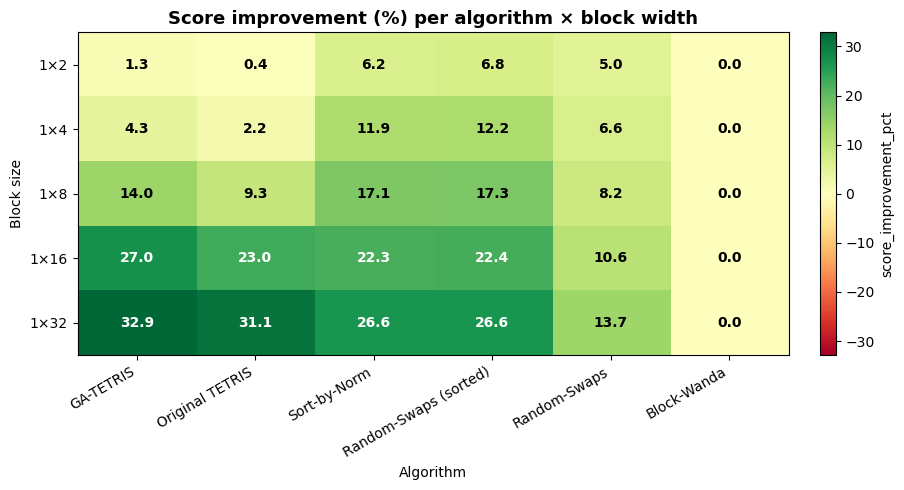

In [23]:
def figure_master_heatmap(data, value_col="score_improvement_pct",
                          title=None, fmt="{:.1f}", cmap="RdYlGn"):
    """Heatmap: rows = block widths, columns = algorithms, cell = mean value."""
    pivot = (data.groupby(["algorithm", "block_width"])[value_col]
                 .mean().unstack("algorithm"))

    # Order columns by ALG_ORDER, drop algorithms that aren't present
    cols = [a for a in ALG_ORDER if a in pivot.columns]
    pivot = pivot[cols]

    fig, ax = plt.subplots(figsize=(1.2 * len(cols) + 2, 0.6 * len(pivot) + 2))
    vmax = max(abs(pivot.min().min()), abs(pivot.max().max()))
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=30, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"1×{w}" for w in pivot.index])
    ax.set_xlabel("Algorithm")
    ax.set_ylabel("Block size")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            color = "white" if abs(v) > vmax * 0.6 else "black"
            ax.text(j, i, fmt.format(v), ha="center", va="center",
                    color=color, fontsize=10, fontweight="bold")

    cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
    cbar.set_label(value_col)
    ax.set_title(title or f"{value_col} (mean across all layers)",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


figure_master_heatmap(df_s, value_col="score_improvement_pct",
                     title="Score improvement (%) per algorithm × block width"); plt.show()


## Figure 2 — Score improvement vs block width

When does each algorithm pay off?

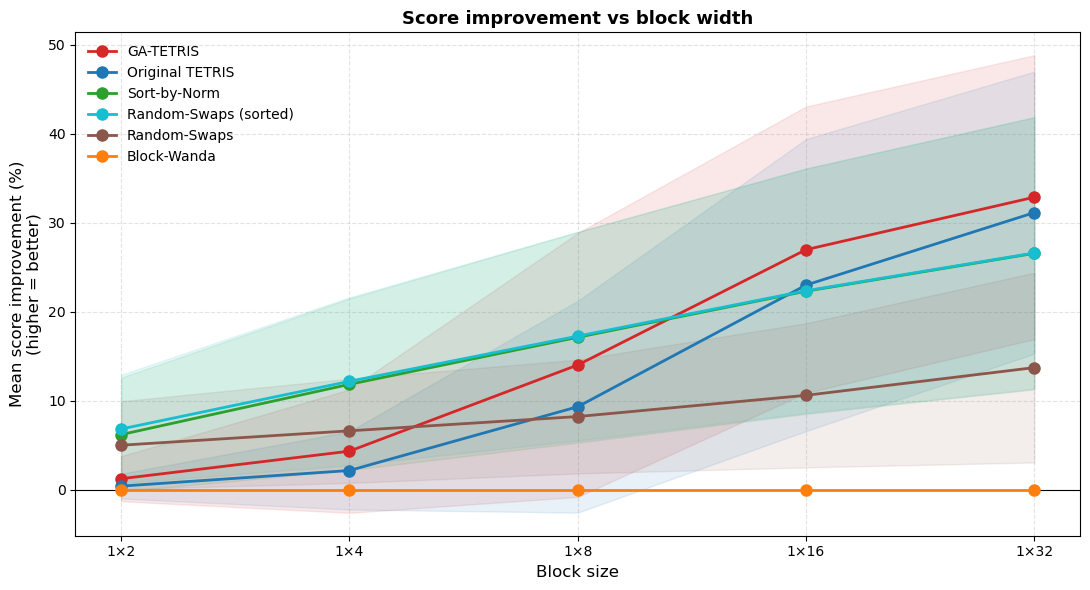

In [24]:
def figure_block_sweep(data, value_col="score_improvement_pct",
                       ylabel="Mean score improvement (%)", title=None,
                       show_band=True, log_x=True):
    """Line plot: x = block width, y = mean value, line per algorithm."""
    agg = (data.groupby(["algorithm", "block_width"])[value_col]
                .agg(["mean", "std", "count"]).reset_index())
    algs = sorted(agg.algorithm.unique(), key=alg_sort_key)

    fig, ax = plt.subplots(figsize=(11, 6))
    for a in algs:
        sub = agg[agg.algorithm == a].sort_values("block_width")
        if len(sub) <= 1: continue
        c = alg_color(a)
        ax.plot(sub["block_width"], sub["mean"], marker="o", linewidth=2.0,
                markersize=8, color=c, label=a, zorder=3)
        if show_band and sub["std"].notna().any():
            ax.fill_between(sub["block_width"],
                            sub["mean"] - sub["std"], sub["mean"] + sub["std"],
                            color=c, alpha=0.10, zorder=2)

    ax.axhline(0, color="black", linewidth=0.8)
    if log_x:
        ax.set_xscale("log", base=2)
        widths = sorted(data["block_width"].unique())
        ax.set_xticks(widths)
        ax.set_xticklabels([f"1×{w}" for w in widths])
    ax.set_xlabel("Block size", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title or f"{value_col} vs block width", fontsize=13, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(loc="best", frameon=False, fontsize=10)
    fig.tight_layout()
    return fig


figure_block_sweep(df_s, value_col="score_improvement_pct",
                   ylabel="Mean score improvement (%)\n(higher = better)",
                   title="Score improvement vs block width"); plt.show()


## Figure 3 — Accuracy vs block width

How wide can you go before pruning destroys task accuracy?

This figure only renders if `accuracy_all_layers` was filled in (i.e. you ran with `SKIP_ACCURACY=False`).

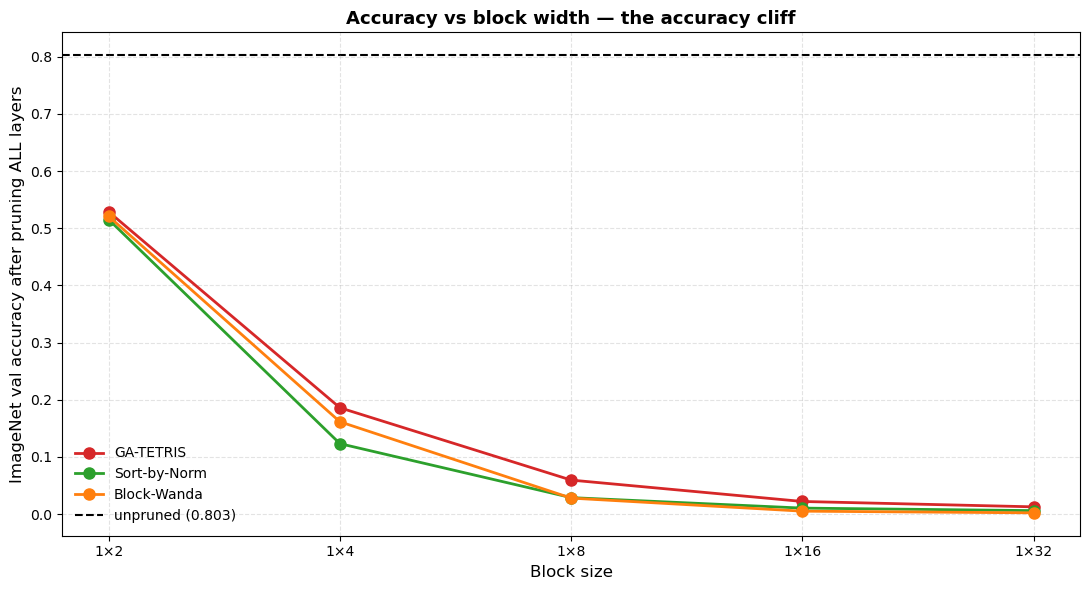

In [25]:
acc_col = "accuracy_all_layers"

if acc_col in df_s.columns and df_s[acc_col].notna().any():
    # Per-experiment accuracy is constant within (algorithm, block_size, sparsity).
    # Take .first() and drop NaN entries.
    acc_data = (df_s.groupby(["algorithm", "block_width"])[acc_col]
                    .first().reset_index().dropna(subset=[acc_col]))

    algs = sorted(acc_data.algorithm.unique(), key=alg_sort_key)
    fig, ax = plt.subplots(figsize=(11, 6))
    for a in algs:
        sub = acc_data[acc_data.algorithm == a].sort_values("block_width")
        if len(sub) <= 1: continue
        ax.plot(sub["block_width"], sub[acc_col], marker="o", linewidth=2.0,
                markersize=8, color=alg_color(a), label=a, zorder=3)

    # Baseline reference line
    if "baseline_accuracy" in df_s.columns and df_s["baseline_accuracy"].notna().any():
        baseline = df_s["baseline_accuracy"].dropna().iloc[0]
        ax.axhline(baseline, color="black", linewidth=1.5, linestyle="--",
                   label=f"unpruned ({baseline:.3f})", zorder=1)

    ax.set_xscale("log", base=2)
    widths = sorted(acc_data["block_width"].unique())
    ax.set_xticks(widths)
    ax.set_xticklabels([f"1×{w}" for w in widths])
    ax.set_xlabel("Block size", fontsize=12)
    ax.set_ylabel("ImageNet val accuracy after pruning ALL layers", fontsize=12)
    ax.set_title("Accuracy vs block width — the accuracy cliff",
                 fontsize=13, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(loc="best", frameon=False, fontsize=10)
    fig.tight_layout()
    plt.show()
else:
    print("No accuracy_all_layers data — re-run experiments with SKIP_ACCURACY=False.")


## Figure 4 — Score vs accuracy tradeoff

Twin-axis overlay of figures 2 and 3: score improvement going up, accuracy going down. The crossover region — where score gains are big but accuracy still survives — is the practical operating range.

For readability, plotted only for two algorithms: **GA-TETRIS** (best score-improving) and **Block-Wanda** (the no-permutation baseline).

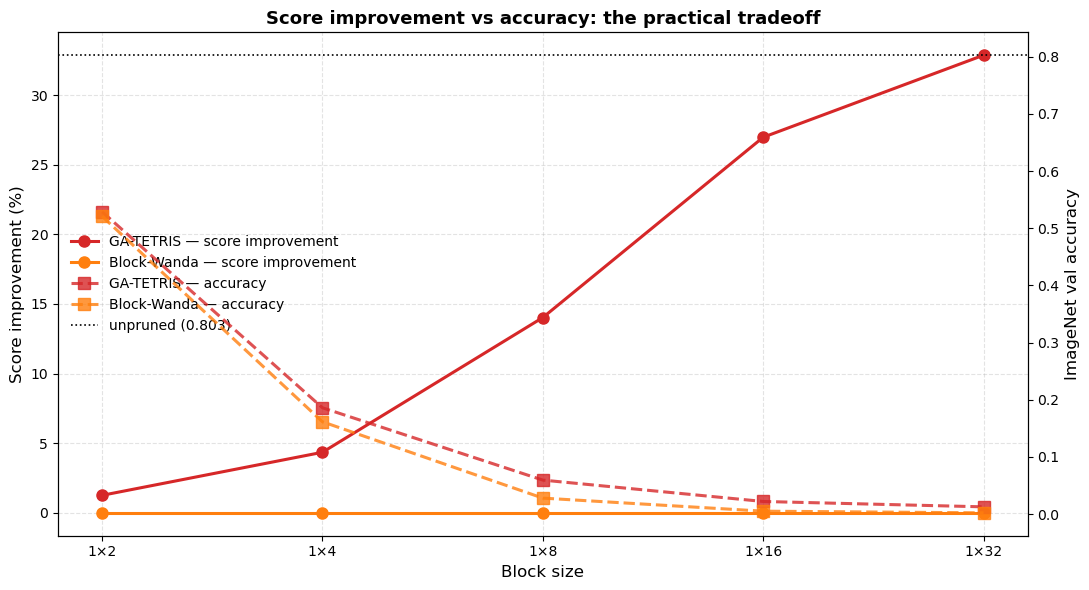

In [26]:
focus_algs = ["GA-TETRIS", "Block-Wanda"]
acc_col = "accuracy_all_layers"

if acc_col in df_s.columns and df_s[acc_col].notna().any():
    fig, ax_score = plt.subplots(figsize=(11, 6))
    ax_acc = ax_score.twinx()

    for a in focus_algs:
        sub_score = (df_s[df_s.algorithm == a]
                     .groupby("block_width")["score_improvement_pct"]
                     .mean().reset_index().sort_values("block_width"))
        sub_acc = (df_s[df_s.algorithm == a]
                   .groupby("block_width")[acc_col]
                   .first().reset_index().dropna().sort_values("block_width"))
        c = alg_color(a)

        if len(sub_score) > 1:
            ax_score.plot(sub_score["block_width"], sub_score["score_improvement_pct"],
                          marker="o", linewidth=2.2, markersize=8, color=c,
                          label=f"{a} — score improvement", zorder=3)
        if len(sub_acc) > 1:
            ax_acc.plot(sub_acc["block_width"], sub_acc[acc_col],
                        marker="s", linewidth=2.2, markersize=8, color=c,
                        linestyle="--", label=f"{a} — accuracy", zorder=3, alpha=0.8)

    if "baseline_accuracy" in df_s.columns and df_s["baseline_accuracy"].notna().any():
        baseline = df_s["baseline_accuracy"].dropna().iloc[0]
        ax_acc.axhline(baseline, color="black", linewidth=1.2, linestyle=":",
                       label=f"unpruned ({baseline:.3f})", zorder=1)

    ax_score.set_xscale("log", base=2)
    widths = sorted(df_s["block_width"].unique())
    ax_score.set_xticks(widths)
    ax_score.set_xticklabels([f"1×{w}" for w in widths])
    ax_score.set_xlabel("Block size", fontsize=12)
    ax_score.set_ylabel("Score improvement (%)", fontsize=12)
    ax_acc.set_ylabel("ImageNet val accuracy", fontsize=12)
    ax_score.grid(True, linestyle="--", alpha=0.35)
    ax_score.set_title("Score improvement vs accuracy: the practical tradeoff",
                       fontsize=13, fontweight="bold")

    h1, l1 = ax_score.get_legend_handles_labels()
    h2, l2 = ax_acc.get_legend_handles_labels()
    ax_score.legend(h1 + h2, l1 + l2, loc="center left",
                    frameon=False, fontsize=10)
    fig.tight_layout()
    plt.show()
else:
    print("No accuracy data, skipping the tradeoff figure.")


## Figure 5 — Per-layer comparison: narrow (1×2) vs wide (1×16)

Two side-by-side panels showing how the algorithm ranking shifts across layer types as block width changes.

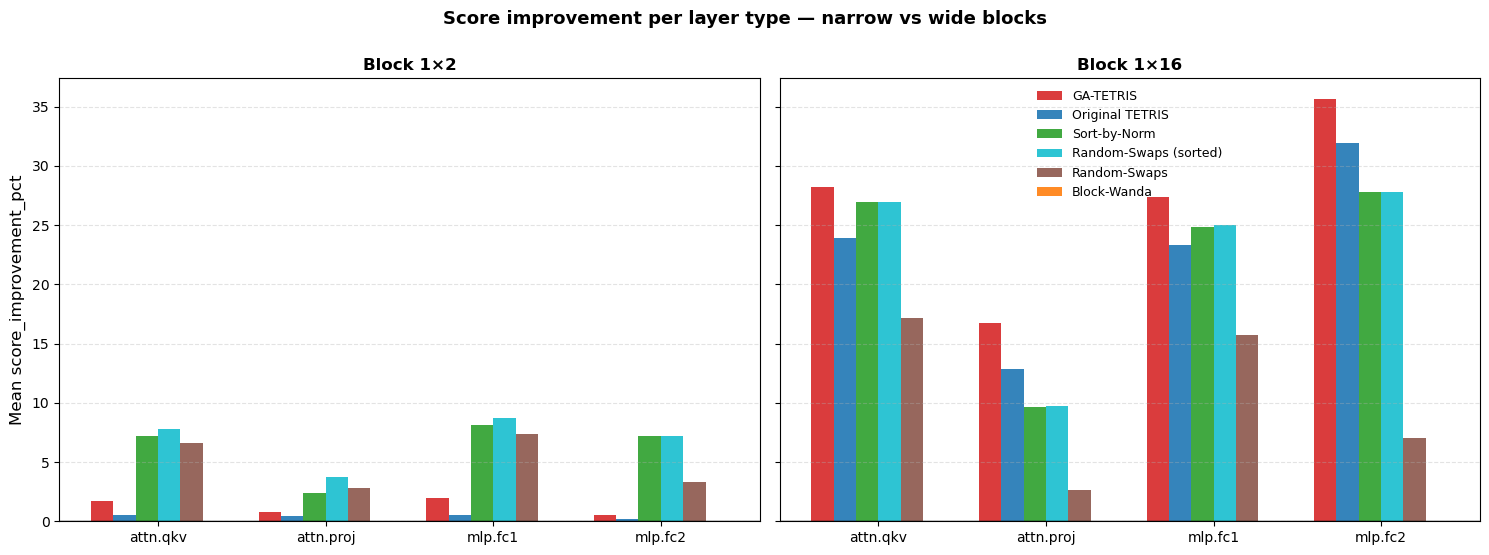

In [27]:
NARROW_W = 2
WIDE_W = 16

def figure_per_layer_type_pair(data, narrow_w, wide_w, value_col="score_improvement_pct"):
    """Two-panel bar chart: score improvement per layer type, at two block widths."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

    for ax, w in zip(axes, [narrow_w, wide_w]):
        sub = data[data.block_width == w]
        agg = (sub.groupby(["layer_type", "algorithm"])[value_col]
                  .mean().unstack("algorithm")
                  .reindex([lt for lt in LAYER_TYPES if lt in sub.layer_type.unique()]))
        algs = [a for a in ALG_ORDER if a in agg.columns]
        agg = agg[algs]

        x = np.arange(len(agg.index))
        width = 0.8 / max(len(algs), 1)
        for k, a in enumerate(algs):
            ax.bar(x + k * width, agg[a].values, width,
                   color=alg_color(a), label=a, alpha=0.9)

        ax.axhline(0, color="black", linewidth=1.0)
        ax.set_xticks(x + width * (len(algs) - 1) / 2)
        ax.set_xticklabels(agg.index)
        ax.set_title(f"Block 1×{w}", fontsize=12, fontweight="bold")
        ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    axes[0].set_ylabel(f"Mean {value_col}", fontsize=12)
    axes[1].legend(loc="best", frameon=False, fontsize=9)
    fig.suptitle(f"Score improvement per layer type — narrow vs wide blocks",
                 fontsize=13, fontweight="bold", y=1.00)
    fig.tight_layout()
    return fig


figure_per_layer_type_pair(df_s, NARROW_W, WIDE_W); plt.show()


## Figure 6 — Validation: does the cheap score metric track the real one?

Per-layer scatter: x = score improvement vs Block-Wanda, y = ΔÃƒrel_error vs Block-Wanda. A tight diagonal cluster means the score metric is doing its job — algorithms that improve score also reduce weight-space error. Pearson r in the title quantifies this.

Pooled across all algorithms and one chosen block width.

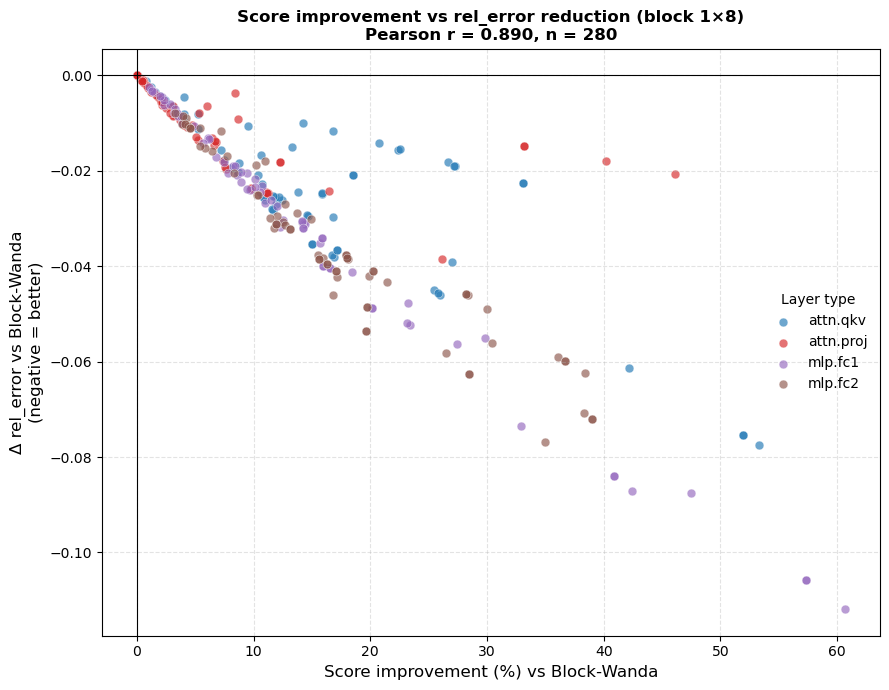

In [28]:
VALIDATE_W = 8

def figure_score_vs_rel_error(data, block_width):
    """Scatter: per-layer (score_improvement_pct) vs (Δ rel_error vs Block-Wanda)."""
    sub = data[data.block_width == block_width].copy()
    if "Block-Wanda" not in sub.algorithm.unique():
        print(f"Block-Wanda not found at block_width={block_width}, can't compute deltas.")
        return None

    bw_ref = (sub[sub.algorithm == "Block-Wanda"]
              .set_index(["layer_type", "layer_idx"])["rel_error"])

    rows = []
    for alg in sub.algorithm.unique():
        if alg in ("Block-Wanda", "No prune"): continue
        a_sub = sub[sub.algorithm == alg].set_index(["layer_type", "layer_idx"])
        for (lt, li), row in a_sub.iterrows():
            if (lt, li) not in bw_ref.index: continue
            rows.append({
                "algorithm": alg,
                "layer_type": lt,
                "score_improvement_pct": row["score_improvement_pct"],
                "rel_error_delta": row["rel_error"] - bw_ref[(lt, li)],
            })
    comp = pd.DataFrame(rows)
    if len(comp) == 0:
        print("No comparison rows.")
        return None

    fig, ax = plt.subplots(figsize=(9, 7))
    for lt in LAYER_TYPES:
        s = comp[comp.layer_type == lt]
        if len(s) == 0: continue
        ax.scatter(s["score_improvement_pct"], s["rel_error_delta"],
                   color=layer_color(lt), label=lt, s=40, alpha=0.65,
                   edgecolor="white", linewidth=0.4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    r = comp["score_improvement_pct"].corr(-comp["rel_error_delta"])
    ax.set_xlabel("Score improvement (%) vs Block-Wanda", fontsize=12)
    ax.set_ylabel("Δ rel_error vs Block-Wanda\n(negative = better)", fontsize=12)
    ax.set_title(f"Score improvement vs rel_error reduction (block 1×{block_width})\n"
             f"Pearson r = {r:.3f}, n = {len(comp)}",
             fontsize=12, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(title="Layer type", frameon=False, loc="best", fontsize=10)
    fig.tight_layout()
    return fig


figure_score_vs_rel_error(df_s, VALIDATE_W); plt.show()


## Figure 7 — Pruning time (cost of each algorithm)

Mean per-layer wall-clock time. Log scale because GA-TETRIS is orders of magnitude slower than Block-Wanda. Aggregated across all layers; the band shows std.

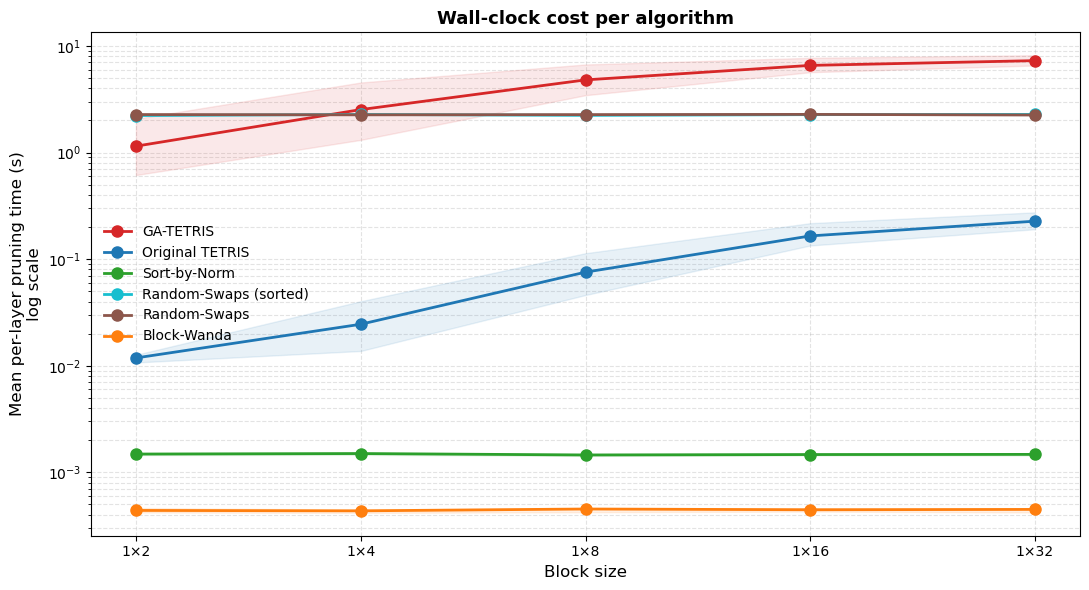

In [29]:
def figure_time(data):
    # Per-block per-algorithm mean (so each (alg, block_width) gets one number per layer_idx)
    per_block = (data.groupby(["algorithm", "block_width", "layer_idx"])
                 ["total_time_sec"].mean().reset_index())
    agg = (per_block.groupby(["algorithm", "block_width"])["total_time_sec"]
           .agg(mean="mean", q10=lambda s: s.quantile(0.1),
                q90=lambda s: s.quantile(0.9)).reset_index())

    algs = sorted(agg.algorithm.unique(), key=alg_sort_key)
    fig, ax = plt.subplots(figsize=(11, 6))
    for a in algs:
        sub = agg[agg.algorithm == a].sort_values("block_width")
        if len(sub) <= 1: continue
        c = alg_color(a)
        ax.plot(sub["block_width"], sub["mean"], marker="o", linewidth=2.0,
                markersize=8, color=c, label=a, zorder=3)
        ax.fill_between(sub["block_width"], sub["q10"], sub["q90"],
                        color=c, alpha=0.10, zorder=2)

    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    widths = sorted(data["block_width"].unique())
    ax.set_xticks(widths)
    ax.set_xticklabels([f"1×{w}" for w in widths])
    ax.set_xlabel("Block size", fontsize=12)
    ax.set_ylabel("Mean per-layer pruning time (s)\nlog scale", fontsize=12)
    ax.set_title("Wall-clock cost per algorithm", fontsize=13, fontweight="bold")
    ax.grid(True, which="both", linestyle="--", alpha=0.35)
    ax.legend(loc="best", frameon=False, fontsize=10)
    fig.tight_layout()
    return fig


figure_time(df_s); plt.show()
